In [1]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib widget

## Numpy arrays are fast

The use of _vectorization_ techniques employed by `numpy` make it much faster than built-in Python lists. We use the `%time` magic command to profile a piece of code in a notebook cell.

In [2]:
my_arr = np.arange(1000000)

In [3]:
%time for _ in range(10): my_arr_1 = my_arr * 2

CPU times: user 3.75 ms, sys: 6.94 ms, total: 10.7 ms
Wall time: 9.96 ms


In [4]:
my_list = list(range(1000000))

In [5]:
%time for _ in range(10): my_arr_2 = [x * 2 for x in my_list]

CPU times: user 207 ms, sys: 71 ms, total: 278 ms
Wall time: 278 ms


## Basic numpy array operations

Pre-filled arrays of various dimensions.

In [6]:
print(np.zeros(5, dtype=int))
print(np.zeros((2, 3)))

print(np.ones(5))
print(np.ones((2, 3)))

# identity matrix
print(np.eye(5))

[0 0 0 0 0]
[[0. 0. 0.]
 [0. 0. 0.]]
[1. 1. 1. 1. 1.]
[[1. 1. 1.]
 [1. 1. 1.]]
[[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]


Generate arrays pre-populated with random numbers:

Text(0, 0.5, 'Frequency')

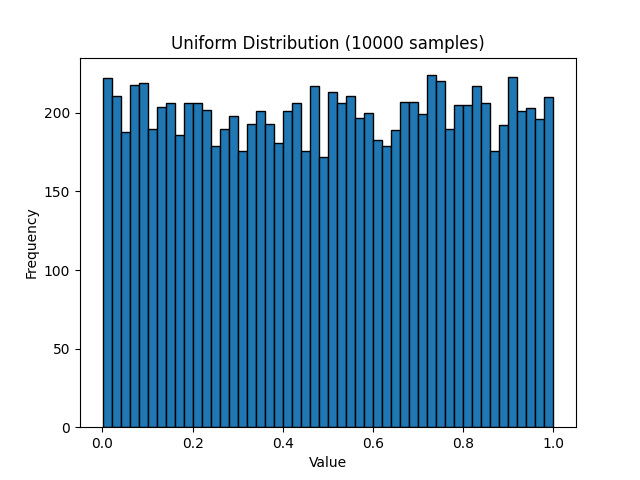

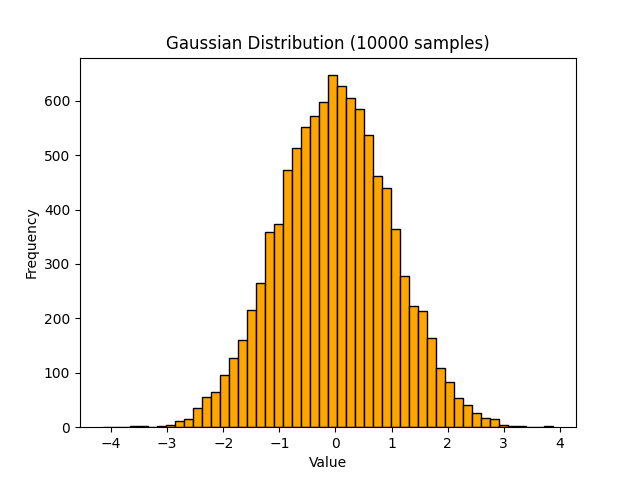

In [7]:
num_vals = 10000
rand_arr_1 = np.random.rand(num_vals)

plt.figure()
plt.hist(rand_arr_1, bins=50, edgecolor='black')
plt.title(f"Uniform Distribution ({num_vals} samples)")
plt.xlabel("Value")
plt.ylabel("Frequency")

gaussian_arr = np.random.randn(num_vals)
plt.figure()
plt.hist(gaussian_arr, bins=50, edgecolor='black', color='orange')
plt.title(f"Gaussian Distribution ({num_vals} samples)")
plt.xlabel("Value")
plt.ylabel("Frequency")

Numbers in an interval (with optional step)

In [8]:
arr_1 = np.arange(-5, 5, .5)
print(arr_1)
print(np.shape(arr_1))

[-5.  -4.5 -4.  -3.5 -3.  -2.5 -2.  -1.5 -1.  -0.5  0.   0.5  1.   1.5
  2.   2.5  3.   3.5  4.   4.5]
(20,)


Evenly distributed values in an interval (to not be confused with `arange`).

In [9]:
print(np.linspace(0, 20, 11, dtype=int))

[ 0  2  4  6  8 10 12 14 16 18 20]


Using `meshgrid` functions we can calculate the values for an entire 2D surface at once.

Text(0.5, 1.0, 'Image plot for $\\sqrt{x^2 + y^2}$ for a grid of values.')

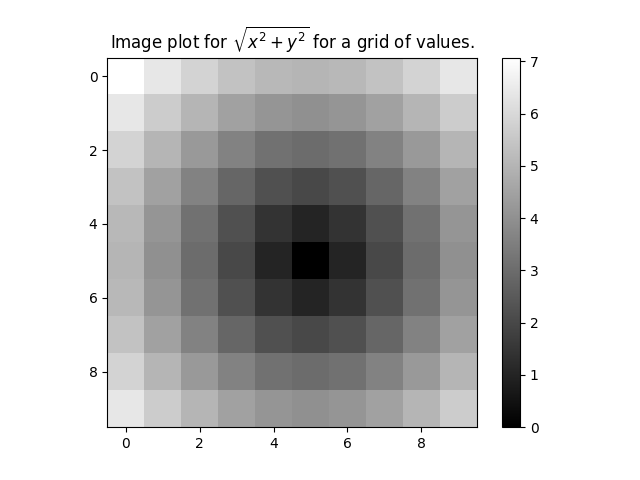

In [10]:
arr_1 = np.arange(-5, 5)
xs, ys = np.meshgrid(arr_1, arr_1)
zs = np.sqrt(xs ** 2 + ys ** 2)

plt.figure()
plt.imshow(zs, cmap=plt.cm.gray)
plt.colorbar()
plt.title(r"Image plot for $\sqrt{x^2 + y^2}$ for a grid of values.")

Reshape an existing array.

In [11]:
arr_2 = np.arange(100).reshape(10, 10)
print(arr_2)

[[ 0  1  2  3  4  5  6  7  8  9]
 [10 11 12 13 14 15 16 17 18 19]
 [20 21 22 23 24 25 26 27 28 29]
 [30 31 32 33 34 35 36 37 38 39]
 [40 41 42 43 44 45 46 47 48 49]
 [50 51 52 53 54 55 56 57 58 59]
 [60 61 62 63 64 65 66 67 68 69]
 [70 71 72 73 74 75 76 77 78 79]
 [80 81 82 83 84 85 86 87 88 89]
 [90 91 92 93 94 95 96 97 98 99]]


Various methods available on arrays.

In [12]:
arr = np.random.randint(0, 100, 20)
print(f"Shape: {arr.shape}")
print(f"DType: {arr.dtype}")

print("\n\n----------")

# min/max/sum/avg
print("Min / Max / Sum / Avg")
print(f"Min: {arr.min()} @ {arr.argmin()}")
print(f"Max: {arr.max()} @ {arr.argmax()}")
print(f"Sum: {arr.sum()}")
print(f"Avg: {arr.mean()}")

print("\n\n----------")

# cummulative sum
print("Cumulative sum")
arr_2.cumsum(axis=1)

Shape: (20,)
DType: int64


----------
Min / Max / Sum / Avg
Min: 4 @ 2
Max: 99 @ 3
Sum: 1162
Avg: 58.1


----------
Cumulative sum


array([[  0,   1,   3,   6,  10,  15,  21,  28,  36,  45],
       [ 10,  21,  33,  46,  60,  75,  91, 108, 126, 145],
       [ 20,  41,  63,  86, 110, 135, 161, 188, 216, 245],
       [ 30,  61,  93, 126, 160, 195, 231, 268, 306, 345],
       [ 40,  81, 123, 166, 210, 255, 301, 348, 396, 445],
       [ 50, 101, 153, 206, 260, 315, 371, 428, 486, 545],
       [ 60, 121, 183, 246, 310, 375, 441, 508, 576, 645],
       [ 70, 141, 213, 286, 360, 435, 511, 588, 666, 745],
       [ 80, 161, 243, 326, 410, 495, 581, 668, 756, 845],
       [ 90, 181, 273, 366, 460, 555, 651, 748, 846, 945]])

## Array Indexing

In [13]:
arr = np.random.randint(0, 100, 20)

# slicing works similar with Python built-in lists
# NOTE: for optimization reasons, slices do not copy data in a separate array
print(arr[:5])
print(arr[3:8])

# you ca create a copy of an array explicitly
arr_copy = arr[3:8].copy()
print(arr_copy)

# numpy arrays have a neat feature called "broadcasting"
# NOTE: when bradcasting over a slice, you also modify the original array
arr[:5] = -1
print(arr)

[75 27 62 95 39]
[95 39  1 42 44]
[95 39  1 42 44]
[-1 -1 -1 -1 -1  1 42 44 46 18 86 38 71 88 31 76  6 79 42 24]


In [14]:
arr_2d = np.arange(5, 46, 5).reshape(3,3)
arr_2d

array([[ 5, 10, 15],
       [20, 25, 30],
       [35, 40, 45]])

Sliced-base selection

In [15]:
# get to one element
print(arr_2d[0][1]) # double-bracket notation
print(arr_2d[0,1]) # single-bracket notation

print(arr_2d[:2])
print(arr_2d[0:2,1:])

10
10
[[ 5 10 15]
 [20 25 30]]
[[10 15]
 [25 30]]


Conditional selection

In [16]:
arr_2d = np.arange(0, 25).reshape(5, 5)

print(arr_2d > 15) # generates a bool array

# we can use bool arrays as index in array selection (acts as "mask")
print(arr_2d[arr_2d > 15]) 

[[False False False False False]
 [False False False False False]
 [False False False False False]
 [False  True  True  True  True]
 [ True  True  True  True  True]]
[16 17 18 19 20 21 22 23 24]


## Array operations

In [17]:
arr = np.arange(0, 11)

# scalar operations
print(arr + 5)
print(arr - 5)
print(arr * 5)
print(arr ** 2)

print("------------")

# element wise addition, subtraction, etc. between 2 arrays
print(arr + arr)
print(arr - arr)
print(arr * arr)
print(arr / arr) # this issues an warning (not error) when dividing by 0

[ 5  6  7  8  9 10 11 12 13 14 15]
[-5 -4 -3 -2 -1  0  1  2  3  4  5]
[ 0  5 10 15 20 25 30 35 40 45 50]
[  0   1   4   9  16  25  36  49  64  81 100]
------------
[ 0  2  4  6  8 10 12 14 16 18 20]
[0 0 0 0 0 0 0 0 0 0 0]
[  0   1   4   9  16  25  36  49  64  81 100]
[nan  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.]


/tmp/ipykernel_30041/36334146.py:15: RuntimeWarning: invalid value encountered in divide
  print(arr / arr) # this issues an warning (not error) when dividing by 0


Universal functions are "broadcasted" across the entire array.

In [18]:
print(np.sqrt(arr))
print(np.max(arr)) # same arr.max()
print(np.sin(arr))

[0.         1.         1.41421356 1.73205081 2.         2.23606798
 2.44948974 2.64575131 2.82842712 3.         3.16227766]
10
[ 0.          0.84147098  0.90929743  0.14112001 -0.7568025  -0.95892427
 -0.2794155   0.6569866   0.98935825  0.41211849 -0.54402111]


In [19]:
y = np.array([ [1, 1, 1], [2 ,2, 2] ])

# matric transposition
y.T

# matrix multiplication
y @ y.T

array([[ 3,  6],
       [ 6, 12]])